In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw06.ipynb")

# 🎲 Homework 6: Probability (and a little bit of gradient descent)
## Due Date: Friday, November 7th, 11:59 PM PDT

**‼️ Note: There is also a written portion of this HW! Be sure to complete both this notebook and the written assignment.**

You must submit this assignment to Pensieve by the on-time deadline, Friday, November 7th, 11:59 PM PDT. Please read the syllabus for the Slip Day policy. No late submissions beyond what is outlined in the Slip Day policy will be accepted. **We strongly encourage you to submit your work to Pensieve several hours before the stated deadline.** This way, you will have ample time to reach out to staff for support if you encounter difficulties with submission. While course staff is happy to help guide you with submitting your assignment ahead of the deadline, we will not respond to last-minute requests for assistance.

Please read the instructions carefully when submitting your work to Pensieve. 

This is part of a two-part assignment. After completing this part ("Homework 6 Coding"), also remember to complete the "Homework 6 (Statistics)" assignment, which will be about deriving the mathematical aspects of random variables and estimators to help you in upcoming statistics courses during your time at Berkeley.


## Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the homework, we ask that you **write your solutions individually**. If you do discuss the assignments with others please **include their names** below.

**Collaborators**: *list collaborators here*

## Introduction

In this homework, we will explore a dataset of the 2022 U.S. News & World Report rankings for liberal arts colleges.
The dataset in this HW is a simplified version of the [original data source](https://andyreiter.com/datasets/). (Note: we are using the 2022 version, not the updated 2026 version)

While working on this notebook, you will gain experience with the following:
* Bootstrap sampling,
* The bias-variance tradeoff and decomposition,
* Multicollinearity in features, and
* Gradient Descent.

## Grading
Grading is broken down into auto-graded answers and free responses. 

For auto-graded answers, the results of your code are compared to provided and/or hidden tests.

For free response, readers will evaluate how well you answered the question and/or fulfilled the requirements of the question. 

### Score breakdown

Question | Manual | Points
--- |---| ---
1a| No | 2
1b| No | 3
1c| Yes | 3
1d| Yes | 2
1e| Yes | 1
2a| No | 3
2b| Yes |3
2c| Yes | 1
3a| No | 2
3b| No | 2
3c| No | 2
3d(i)| Yes | 1.5
3d(ii)| Yes | 1.5
4a(i)| Yes | 2
4a(ii)| Yes | 2
4a(iii)| Yes | 2
4b| Yes | 2
5a| No | 0
5b| Yes | 0
Total | 12 | 35

If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). 

In [2]:
# Run this cell to set up your notebook
import numpy as np
import pandas as pd
import sklearn.linear_model as lm
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

import scipy.stats
from hw06_utils import visualize_gradient_descent, plot_function, generate_X, generate_Y

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.precision', 3)

<br/>

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 📈 Question 1: Exploratory Data Analysis

Let's perform some initial EDA to identify trends and patterns in the college ranking dataset.

In [3]:
# Run this cell to load the data; no further action is needed.
college_data = pd.read_csv('data/2022_college_rankings.csv')
college_data.head(5)

,Institution,Type,Overall Score (0-100),Peer Assessment Score (1-5),Graduation and retention rank,Predicted 6yr graduation rate,Actual 6yr graduation rate,Pell gradrate,Social Mobility Rank,Percent of classes under 20,Percent of classes of 50 or more students,Student Excellence rank,First year students in top 10% of high school class,Acceptance rate,Financial resources rank,Average alumni giving rate
0,Williams College (MA),private,100,4.7,1,95%,96%,96%,98.0,84%,1%,1,95%,15%,2.0,47%
1,Amherst College (MA),private,98,4.6,2,92%,95%,93%,38.0,80%,2%,5,85%,12%,5.0,42%
2,Swarthmore College (PA),private,94,4.6,2,92%,97%,98%,135.0,76%,1%,3,93%,9%,6.0,31%
3,Pomona College (CA),private,93,4.5,6,92%,94%,91%,80.0,78%,0.20%,3,90%,9%,8.0,23%
4,Wellesley College (MA),private,92,4.5,14,92%,94%,95%,98.0,71%,0.20%,8,85%,20%,8.0,40%


The granularity of the dataset is an individual **college**; each row includes metrics, ratings, and features of **one college in the U.S**.

Here are the columns in the dataset:
* `Institution`: The name of the college
* `Type`: Whether the college is `'private'` or `'public'`
* `Overall Score (0-100)`: The score computed by U.S. News & World Report to generate the ranking. **This is our outcome variable.**
* The remaining columns contain features that are related to each college's overall score. 

We can use `college_data.info()` and `college_data.describe()` to see various statistics about the features of the provided college ranking data. Do any particular statistics stand out to you? Which might be useful when modeling?

**Note:** This isn't a question, so it's not worth any points. This is just food for thought as you start to explore the dataset.

In [4]:
college_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 16 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Institution                                          167 non-null    object 
 1   Type                                                 167 non-null    object 
 2   Overall Score (0-100)                                167 non-null    int64  
 3   Peer Assessment Score (1-5)                          167 non-null    float64
 4   Graduation and retention rank                        167 non-null    int64  
 5   Predicted 6yr graduation rate                        167 non-null    object 
 6   Actual 6yr graduation rate                           167 non-null    object 
 7   Pell gradrate                                        154 non-null    object 
 8   Social Mobility Rank                                 161 non-null    f

In [5]:
college_data.describe()

,Overall Score (0-100),Peer Assessment Score (1-5),Graduation and retention rank,Social Mobility Rank,Student Excellence rank,Financial resources rank
count,167.000,167.000,167.000,161.000,167.000,167.000
mean,62.012,3.240,83.281,110.491,86.341,88.551
std,14.977,0.608,50.093,59.655,53.451,53.912
min,40.000,2.200,1.000,3.000,1.000,1.000
25%,49.500,2.750,42.000,67.000,41.000,42.000
50%,59.000,3.100,84.000,115.000,84.000,85.000
75%,72.000,3.600,121.000,158.000,128.500,127.000
max,100.000,4.700,191.000,212.000,212.000,222.000


You may have observed that several features in the dataset are not shown when viewing with the `describe()` method. This is because those features are non-numeric. For example, some features are in the string format `"XX%"`.

Before we can fit a linear model accounting for all features in the dataset, we have to convert all features to a numeric representation.

<br>

---

### Question 1a

Create a new `DataFrame` `cleaned_college_data` with the following changes:

- For each column containing at least one missing value, add a new Boolean column that is `True` when the column value is missing, and `False` when the column value is not missing.
    - For example, if there were a column containing the values `1, 2, NaN`, we would add a column containing the values `False, False, True`.
    - If the original column name is `COLUMN`, the added column name should be `COLUMN_missing`. 

**Hint**: Use a `for` loop to iterate over the existing column names. You may find the `any()` function [(documentation)](https://docs.python.org/3/library/functions.html#any) useful.


In [6]:
cleaned_college_data = college_data.copy()

for col in college_data.columns:
    if college_data[col].isna().any():
        cleaned_college_data[col + "_missing"] = college_data[col].isna()

cleaned_college_data.head()

,Institution,Type,Overall Score (0-100),Peer Assessment Score (1-5),Graduation and retention rank,Predicted 6yr graduation rate,Actual 6yr graduation rate,Pell gradrate,Social Mobility Rank,Percent of classes under 20,...,First year students in top 10% of high school class,Acceptance rate,Financial resources rank,Average alumni giving rate,Pell gradrate_missing,Social Mobility Rank_missing,Percent of classes under 20_missing,Percent of classes of 50 or more students_missing,First year students in top 10% of high school class_missing,Average alumni giving rate_missing
0,Williams College (MA),private,100,4.7,1,95%,96%,96%,98.0,84%,...,95%,15%,2.0,47%,False,False,False,False,False,False
1,Amherst College (MA),private,98,4.6,2,92%,95%,93%,38.0,80%,...,85%,12%,5.0,42%,False,False,False,False,False,False
2,Swarthmore College (PA),private,94,4.6,2,92%,97%,98%,135.0,76%,...,93%,9%,6.0,31%,False,False,False,False,False,False
3,Pomona College (CA),private,93,4.5,6,92%,94%,91%,80.0,78%,...,90%,9%,8.0,23%,False,False,False,False,False,False
4,Wellesley College (MA),private,92,4.5,14,92%,94%,95%,98.0,71%,...,85%,20%,8.0,40%,False,False,False,False,False,False


In [7]:
grader.check("q1a")

q1a results: All test cases passed!

<br>

---

### Question 1b

Now, we will convert all non-numeric columns of `cleaned_college_data` into numbers. Additionally, we will create some new columns to encode additional information.

To do so, complete the following tasks **in the order they are listed**:
1. Consider the columns that contain the `'%'` symbol in any entry. Convert these columns from a string representation into the floating point number preceding `'%'`.
    - For example, the string `"96.4%"` should be converted into floating point number `96.4`.
2. Create a column called `"Is Public"` where the value is `1` if the row's college is public and `0` if the row's college is private.
3. Create a column called `"Is Private"` where the value is `1` if the row's college is private and `0` if the row's college is public.
4. Remove the `"Type"` and `"Institution"` columns.
5. Replace all `NaN` values in the data with the mean of their respective column.

**Hint**:
- `pd.Series.fillna()` [(documentation)](https://pandas.pydata.org/docs/reference/api/pandas.Series.fillna.html) may come in handy.
- You can select all string columns in a `DataFrame` object `df` with `df.select_dtypes(include=['object'])`[(documentation)](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html). Recall that strings are of the `object` type.

In [8]:
# 1. Convert all "XX%" string columns into floats
for col in cleaned_college_data.select_dtypes(include=['object']).columns:
    if cleaned_college_data[col].astype(str).str.contains('%').any():
        cleaned_college_data[col] = (
            cleaned_college_data[col].str.replace('%', '', regex=False).astype(float)
        )

# 2 & 3. One-hot encode the Type column
cleaned_college_data["Is Public"] = (cleaned_college_data["Type"] == "public").astype(int)
cleaned_college_data["Is Private"] = (cleaned_college_data["Type"] == "private").astype(int)

# 4. Drop the non-numeric identifier columns
cleaned_college_data = cleaned_college_data.drop(columns=["Type", "Institution"])

# 5. Impute missing values with the column mean
cleaned_college_data = cleaned_college_data.fillna(cleaned_college_data.mean())

cleaned_college_data

,Overall Score (0-100),Peer Assessment Score (1-5),Graduation and retention rank,Predicted 6yr graduation rate,Actual 6yr graduation rate,Pell gradrate,Social Mobility Rank,Percent of classes under 20,Percent of classes of 50 or more students,Student Excellence rank,...,Financial resources rank,Average alumni giving rate,Pell gradrate_missing,Social Mobility Rank_missing,Percent of classes under 20_missing,Percent of classes of 50 or more students_missing,First year students in top 10% of high school class_missing,Average alumni giving rate_missing,Is Public,Is Private
0,100,4.7,1,95.0,96.0,96.00,98.0,84.0,1.0,1,...,2.0,47.000,False,False,False,False,False,False,0,1
1,98,4.6,2,92.0,95.0,93.00,38.0,80.0,2.0,5,...,5.0,42.000,False,False,False,False,False,False,0,1
2,94,4.6,2,92.0,97.0,98.00,135.0,76.0,1.0,3,...,6.0,31.000,False,False,False,False,False,False,0,1
3,93,4.5,6,92.0,94.0,91.00,80.0,78.0,0.2,3,...,8.0,23.000,False,False,False,False,False,False,0,1
4,92,4.5,14,92.0,94.0,95.00,98.0,71.0,0.2,8,...,8.0,40.000,False,False,False,False,False,False,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,42,2.4,153,63.0,60.0,44.00,122.0,78.0,0.0,139,...,161.0,20.273,False,False,False,False,False,True,0,1
163,41,2.4,163,69.0,56.0,71.87,106.0,72.0,1.0,101,...,85.0,9.000,True,False,False,False,False,False,0,1
164,40,2.9,174,61.0,50.0,42.00,80.0,73.0,0.0,105,...,194.0,6.000,False,False,False,False,False,False,0,1
165,40,2.4,191,71.0,32.0,33.00,67.0,87.0,0.0,161,...,19.0,33.000,False,False,False,False,True,False,0,1


In [9]:
grader.check("q1b")

q1b results: All test cases passed!

<!-- BEGIN QUESTION -->

<br>

---

### Question 1c

Linear models are sensitive to multicollinearity among the columns of the design matrix. So, let's determine the extent of multicollinearity in the college rankings dataset.

In the following cell, we provide you with `arranged_cleaned_college_data`, which is a copy of `cleaned_college_data` containing just a subset of the columns arranged in a particular order. 

Create a visualization that shows the pairwise correlation between each combination of columns in `arranged_cleaned_college_data`. 

- For 2-D visualizations, consider the `sns.heatmap()` [documentation](https://seaborn.pydata.org/generated/seaborn.heatmap.html). 

- For full credit, title your plot, and set `annot=True`. This makes the plot easier to interpret.

- You may find your plot easier to read with a different color scale. For example, try including `cmap="coolwarm"` inside of `sns.heatmap()`.

**Hint**: Your plot should show $10 \times 10$ values corresponding to the [pairwise correlations](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) of the selected columns in `arranged_cleaned_college_data`:
```
['Overall Score (0-100)', 
'Peer Assessment Score (1-5)', 
'Predicted 6yr graduation rate',
'Actual 6yr graduation rate', 
'Graduation and retention rank', 
'Student Excellence rank',
'Acceptance rate', 
'Financial resources rank', 
'Is Public', 
'Is Private']
```

In [10]:
# Running this cell helps you get a subset of cleaned_college_data with the above columns
arranged_cleaned_college_data = cleaned_college_data[
    ['Overall Score (0-100)', 
     'Peer Assessment Score (1-5)', 
     'Predicted 6yr graduation rate',
     'Actual 6yr graduation rate', 
     'Graduation and retention rank', 
     'Student Excellence rank',
     'Acceptance rate', 
     'Financial resources rank', 
     'Is Public', 
     'Is Private']
]

Your output figure should look similar to the following example:

<center><img src = "images/heatmap.png" width = "600"></center>

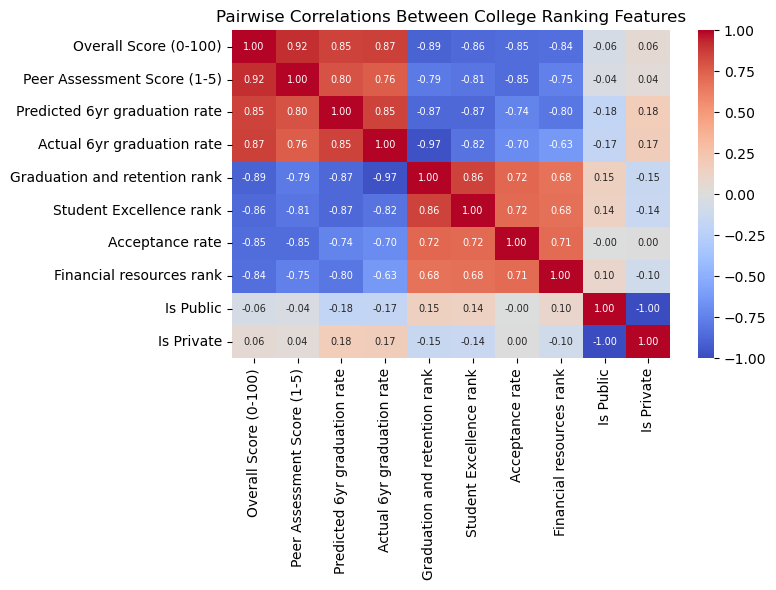

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    arranged_cleaned_college_data.corr(),
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_title("Pairwise Correlations Between College Ranking Features")
plt.tight_layout()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### Question 1d

Do you notice any patterns in the plot from part (c)? What might explain these patterns? Comment and hypothesize on at least two patterns you notice.

Here are some example questions to ponder:

1. Why do some feature-pairs have correlations of $\pm 1$? Is this a problem?
2. What does the correlation between pairs of features (i.e., graduation-related statistics) look like? Is the magnitude of any of the correlations problematically close to 1?
3. Are any features particularly strong predictors of the outcome? If so, why do you think this is the case?
4. Do any features seem potentially redundant? In other words, do you suspect that any features provide similar information about the outcome as other features?


**Pattern 1: `Is Public` and `Is Private` are perfectly negatively correlated ($r = -1$).** Every college in the dataset is either public or private, so `Is Private` $= 1 -$ `Is Public`. The two columns are exact linear functions of one another, which means that together with an intercept column they make the design matrix rank-deficient (perfect multicollinearity). This is a problem: the OLS solution is no longer unique, and individual coefficients become uninterpretable/unstable. The fix is to drop one of the two dummy columns (which is exactly what Question 1e does).

**Pattern 2: the graduation-related features are very strongly correlated with each other.** `Predicted 6yr graduation rate` and `Actual 6yr graduation rate` have a correlation close to $+0.9$, and both are strongly *negatively* correlated with `Graduation and retention rank` (rank 1 is the best school, so higher graduation rates correspond to smaller rank numbers). These features essentially measure the same underlying construct — how successfully a college retains and graduates its students — so they are largely redundant. The correlations are not exactly $\pm 1$, so the model is still fittable, but near-collinearity inflates the variance of the individual coefficients and makes them hard to interpret.

**Pattern 3: some features are very strong predictors of the outcome.** `Peer Assessment Score (1-5)` has a very high positive correlation with `Overall Score (0-100)`, and the rank-based features (`Graduation and retention rank`, `Student Excellence rank`, `Financial resources rank`) all have strong negative correlations with it. This makes sense because U.S. News literally computes the overall score as a weighted combination of these very components, so the "features" are inputs to the outcome by construction rather than independent measurements.

**Pattern 4: `Acceptance rate` is negatively correlated with the overall score.** More selective colleges (low acceptance rate) tend to score higher, and acceptance rate is itself correlated with `Student Excellence rank` and the graduation rates — another sign of redundancy, since selectivity, student quality, and graduation outcomes all move together.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---
### Question 1e
If we tried to fit a linear regression model with an intercept term using all features in `cleaned_college_data`, we might run into some problems when fitting our model.
The Data 100 staff suggests that we perform the following operation to the `DataFrame` before fitting a model:

In [12]:
# You must run this cell to achieve pass the public tests for later questions.
cleaned_college_data = cleaned_college_data.drop('Is Private', axis=1)

Describe the reasoning behind this operation. What problem(s) do we avoid by removing the `Is Private` column from the model fitting process?

Because every college is either public or private, `Is Public` + `Is Private` $= 1$ for every row. If we also include an intercept term, the intercept column (a column of all 1s) is an exact linear combination of these two dummy columns. This is perfect multicollinearity — the "dummy variable trap."

When the design matrix $\mathbb{X}$ has linearly dependent columns it is not full rank, so $\mathbb{X}^T\mathbb{X}$ is singular and cannot be inverted. The normal equations then have infinitely many solutions: there is no unique optimal $\hat{\theta}$. In practice `sklearn` will still return *an* answer (it uses a pseudoinverse), but the individual coefficients are arbitrary, unstable, and uninterpretable, and they can swing wildly across bootstrap resamples — which would wreck the confidence intervals we compute in Question 3.

Dropping `Is Private` removes the redundancy while losing no information: private colleges are simply the baseline category captured by the intercept, and the `Is Public` coefficient now measures the difference between public and private colleges. The design matrix becomes full rank and $\hat{\theta}$ is unique.

<!-- END QUESTION -->

<br/>

<hr style="border: 1px solid #fdb515;" />

## 🏗️ Question 2: Constructing a Preliminary College Ranking Model

In this question, you will fit a linear regression model to predict the U.S. News liberal arts college scores based on college metrics. Later, we will investigate the bias, variance, and observational noise of this model.

<br>

---

### Question 2a

Train an `sklearn` OLS model that predicts each college's overall score using all of the other columns in `cleaned_college_data`. Include an intercept term in the model.

Use `train_test_split()` [(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to evaluate your model's RMSE on a held-out test set containing 33% of the college data; call the resulting splits `X_train`, `X_test`, `Y_train`, and `Y_test`.

You can instantiate your linear regression model using `lm.LinearRegression` [(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

**Note**: To pass the autograder, make sure to include `random_state=100` in your call to `train_test_split()` to generate a reproducible data split ([documentation](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [13]:
# Create train/test sets
X = cleaned_college_data.drop("Overall Score (0-100)", axis=1)
Y = cleaned_college_data["Overall Score (0-100)"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=100
)

# Fit the linear model and make predictions (you will need multiple lines)
model = lm.LinearRegression(fit_intercept=True)
model.fit(X_train, Y_train)
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

# Compute RMSE on train and test sets
train_rmse_cpc = np.sqrt(np.mean((Y_train - Y_train_pred) ** 2))
test_rmse_cpc = np.sqrt(np.mean((Y_test - Y_test_pred) ** 2))

# Ignore these 2 lines of code, they are for later
X_original = X.copy()
Y_original = Y.copy()

train_rmse_cpc, test_rmse_cpc

(np.float64(1.3117596415941), np.float64(2.1437030474881396))

In [14]:
grader.check("q2a")

q2a results: All test cases passed!

<!-- BEGIN QUESTION -->

<br>

---

### Question 2b

Let's visualize the model performance from part 2(a). Plot the following:
1. The observed values vs. the predicted values on the test set.
2. The residuals plot. Recall that for multiple linear regression, we plot the residuals against the predicted values.

**In both plots, the predicted values should be on the x-axis.**

**Note:**
* For a full-credit solution, you should use `plt.subplot()` ([documentation](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)) so that you can view both visualizations side-by-side. 
    * The method `plt.subplot({# of rows}{# of cols}{index of plot})` sets the plottable area to the `index` of a `# rows` by `# cols` grid. 
    * For example, `plt.subplot(121)` sets the plottable area to the first index of a 1x2 plot grid. Calling `Matplotlib` and `Seaborn` functions will plot on the first index. When you're ready to start plotting on the second index, run `plt.subplot(122)`.
* **Remember to add a guiding line to both plots where $\hat{Y} = Y$, i.e., where the residual is 0**.
    * `plt.plot()`[(documentation)](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) and `plt.axhline()`[(documentation)](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html) might be helpful here! 
* Make sure to add descriptive titles and axis labels.
* To avoid distorted aspect ratios, ensure the limits of the x-axes for both plots are the same.

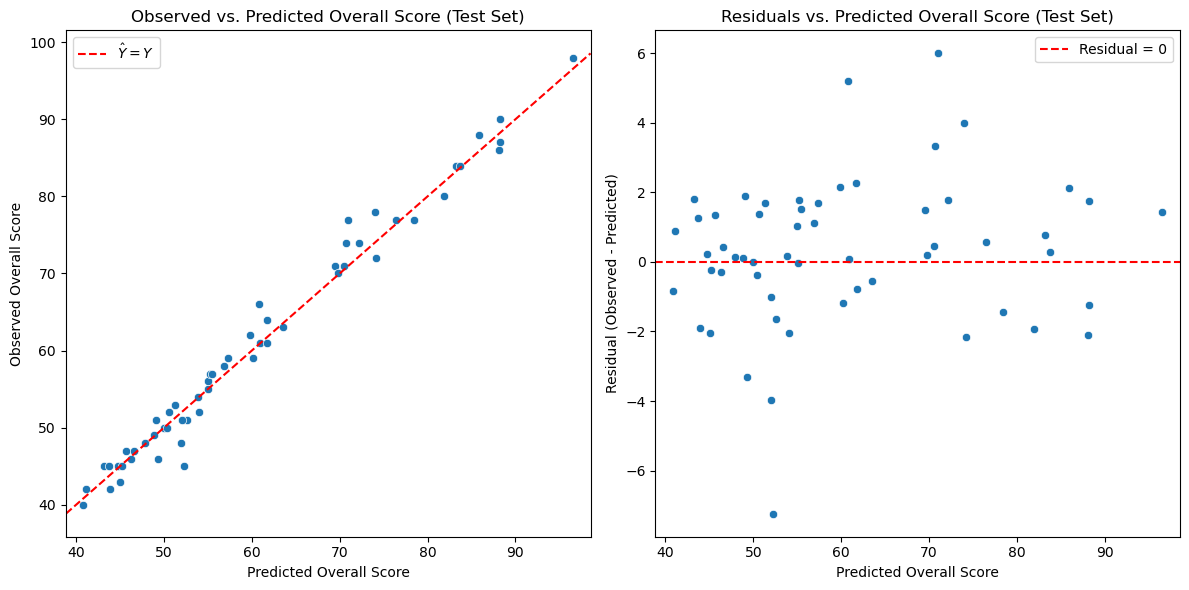

In [15]:
plt.figure(figsize=(12,6))      # do not change this line
plt.subplot(121)                # do not change this line
# 1. plot observations vs. predictions
residuals = Y_test - Y_test_pred
x_lims = [Y_test_pred.min() - 2, Y_test_pred.max() + 2]

sns.scatterplot(x=Y_test_pred, y=Y_test)
plt.plot(x_lims, x_lims, color="red", linestyle="--", label=r"$\hat{Y} = Y$")
plt.xlim(x_lims)
plt.xlabel("Predicted Overall Score")
plt.ylabel("Observed Overall Score")
plt.title("Observed vs. Predicted Overall Score (Test Set)")
plt.legend()

plt.subplot(122)               # do not change this line
# 2. plot residual plot
sns.scatterplot(x=Y_test_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--", label="Residual = 0")
plt.xlim(x_lims)
plt.xlabel("Predicted Overall Score")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs. Predicted Overall Score (Test Set)")
plt.legend()

plt.tight_layout()             # do not change this line

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### Question 2c

Describe what the plots in part (b) indicate about this linear model. In particular, are the predictions good, and do the residuals appear uncorrelated with the predictions?

The predictions are quite good. In the left plot the test points cluster tightly around the $\hat{Y} = Y$ line across the whole range of scores, and the test RMSE (roughly 2 points on a 0–100 scale) is small relative to the spread of the overall scores. This is unsurprising, since the U.S. News overall score is itself constructed as a weighted combination of the very features we are using, so a linear model should fit it well.

The residual plot looks close to what we want from a well-specified linear model: the residuals are scattered above and below the zero line with no obvious curvature or systematic trend as the predicted value changes, i.e., they appear roughly uncorrelated with the predictions. There is a mild hint of heteroscedasticity — the spread of residuals is a bit larger in the middle/lower range of predicted scores than at the very top, where the highly ranked colleges are fit almost exactly — and a few outlying colleges are off by several points. Overall, though, there is no strong evidence that the linear model is missing an important nonlinear pattern.

<!-- END QUESTION -->

<br/>

<hr style="border: 1px solid #fdb515;" />

## 🤹 Question 3: Confidence Intervals and Regression Coefficients

We'll next analyze the statistical significance of coefficients in our linear model. Specifically, we will use bootstrapping to get $95\%$ confidence intervals on the fitted parameters. Each step of bootstrapping corresponds to one part of this question:

1. Question 3(a): Assume the sample is representative of the population from which it was drawn. To generate new, synthetic samples, we resample with replacement from the original sample. Generate `B` resamples.
2. Question 3(b): Calculate a statistic for each of the `B` resamples. Possible statistics are the mean (Lab 9), correlation (Lab 9), coefficients of a linear model (Question 3 below), or any function of the sample data.
3. Question 3(c): Construct a confidence interval by grabbing relevant percentiles of the `B` synthetic summary statistics. For example, for an 80% confidence interval, we grab the 10th and 90th percentiles.
4. Question 3(d): Use the resulting confidence interval to make inferences about the population-level statistic.

<br>

---

### Question 3a

Fill in the blanks below to implement the `bootstrap_sample()` function.

Specification:
- `bootstrap_sample()` returns a list of `B` bootstrap `DataFrame`s of the dataset `data`. 
- To generate a bootstrapped dataset from an actual dataset with $n$ rows, sample $n$ rows uniformly at random *with replacement* so that the bootstrapped `DataFrame` is the same size as the original `DataFrame`.

**Hint**: You may find `df.sample()` helpful, see [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html). This is very similar to Lab 9.

In [16]:
def bootstrap_sample(data, B):
    """
    Performs bootstrap sampling on data to obtain B samples of size n.
    
    Arguments:
        data - Dataset contained as a pandas DataFrame 
        B - Number of randomly drawn samples
    
    Returns:
        samples - List containing B pandas DataFrames of size n each
                  corresponding to each sample  
    """
    return [data.sample(n=len(data), replace=True) for _ in range(B)]

# Print out the first DataFrame only
bootstrap_sample(cleaned_college_data, 1)[0]

,Overall Score (0-100),Peer Assessment Score (1-5),Graduation and retention rank,Predicted 6yr graduation rate,Actual 6yr graduation rate,Pell gradrate,Social Mobility Rank,Percent of classes under 20,Percent of classes of 50 or more students,Student Excellence rank,...,Acceptance rate,Financial resources rank,Average alumni giving rate,Pell gradrate_missing,Social Mobility Rank_missing,Percent of classes under 20_missing,Percent of classes of 50 or more students_missing,First year students in top 10% of high school class_missing,Average alumni giving rate_missing,Is Public
134,48,2.9,117,66.0,70.0,65.0,164.0,55.0,0.0,126,...,78.0,161.0,15.0,False,False,False,False,False,False,0
56,67,3.3,54,78.0,80.0,72.0,150.0,67.0,1.0,56,...,47.0,72.0,19.0,False,False,False,False,False,False,0
117,51,2.6,90,69.0,72.0,65.0,158.0,66.0,1.0,109,...,86.0,89.0,13.0,False,False,False,False,False,False,0
123,50,2.6,105,63.0,68.0,57.0,37.0,82.0,0.3,126,...,93.0,161.0,16.0,False,False,False,False,False,False,0
142,46,2.6,121,59.0,69.0,58.0,98.0,57.0,2.0,169,...,79.0,140.0,15.0,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,72,2.9,42,73.0,84.0,83.0,8.0,100.0,0.0,74,...,86.0,67.0,37.0,False,False,False,False,False,False,0
103,55,2.8,100,76.0,71.0,67.0,164.0,79.0,0.0,105,...,80.0,72.0,15.0,False,False,False,False,False,False,0
14,87,4.0,10,91.0,91.0,90.0,122.0,76.0,0.4,5,...,18.0,29.0,37.0,False,False,False,False,False,False,0
17,84,4.1,23,91.0,90.0,98.0,193.0,68.0,2.0,12,...,10.0,25.0,34.0,False,False,False,False,False,False,0


In [17]:
grader.check("q3a")

q3a results: All test cases passed!

<br>

---

### Question 3b

Write a new function `generate_models()` with the following specifications:

1. Generate 1000 bootstrapped samples from an inputted `DataFrame` called `original_df`. `bootstrap_sample()` will come in handy.
2. For each of the 1000 bootstrapped samples, use `sklearn` to fit a linear regression model (with an intercept term) like we did in Question 2. `Overall Score (0-100)` is the response, and the rest of the columns are features. You should fit 1000 models in total. 
3. Store each of the 1000 trained models in a list called `models`. Return `models`.

**WARNING**: Do not use `X` and `Y` as variable names while bootstrapping, as this will override the values stored in `q2a`.
    
**Hints:**
* You __should not__ create any validation or testing sets in this subpart; each model should fit to one entire bootstrapped `DataFrame`.
* `LinearRegression` is an object type; to store a new model, you must create a new `LinearRegression` instance first!
* When fitting each model, remember that your design matrix should be a 2D array or a `pandas` `DataFrame`, whereas the true labels should be a `Series`.

**Note:** This question may take a few seconds to run due to the number of models being fit. 

In [18]:
np.random.seed(100) # DO NOT REMOVE THIS LINE

def generate_models(original_df):
    datasets = bootstrap_sample(original_df, 1000)
    models = []
    for boot_df in datasets:
        features = boot_df.drop("Overall Score (0-100)", axis=1)
        response = boot_df["Overall Score (0-100)"]
        boot_model = lm.LinearRegression(fit_intercept=True)
        boot_model.fit(features, response)
        models.append(boot_model)
    # Datasets take up a lot of memory, so we should remove them!
    del datasets
    return models


full_feature_models = generate_models(cleaned_college_data)

In [19]:
grader.check("q3b")

q3b results: All test cases passed!

<br>

---

### Question 3c

Complete the `confidence_interval` function below so that it generates a $95\%$ confidence interval for each of our $p+1$ parameters in the original linear model, including the intercept term $\theta_0$. 

Note: All of the helper code needed to extract coefficients from a list of trained models has been implemented for you.

**Hint**: 
- For a refresher on confidence intervals, refer to this section in the [Data 8 textbook](https://inferentialthinking.com/chapters/13/3/Confidence_Intervals.html). 
- Pay close attention to how the arrays used below are formatted. What does each row represent? What does each column represent? To get the $i^{th}$ column from a 2D-array, you can use `2D_array[:, i]`.


In [20]:
def extract_coefs(models, include_intercept = True):
    """
    NOTE: This function has already been implemented. You do not need to modify this!
    
    Extracts coefficients of all the linear regression models in MODELS and returns
    it as a NumPy array with each model's coefficients as one row.
    
    Arguments:
        models - Contains k sklearn LinearRegression models, each with p + 1 coefficients.
        include_intercept - Whether to include an intercept in returned coefficients.
    
    Returns:
        coef_array - Coefficients of all k models, each with p + 1 coefficients (if intercept
                     enabled, otherwise p). The returned object is k x (p + 1) NumPy array.
    """
    coef_array = np.zeros(shape = (len(models), len(models[0].coef_) + 1))
    for i, m in enumerate(models):
        coef_array[i, 0] = m.intercept_
        coef_array[i, 1:] = m.coef_
    if include_intercept:
        return coef_array 
    return coef_array[:, 1:]

def confidence_interval(coefs):
    """
    Calculates confidence intervals for each theta_i based on coefficients of 
    bootstrapped models. Returns output as a list of confidence intervals.
    
    Arguments:
        coefs - Output of extract_coefs, a k x (p + 1) or k x p NumPy array containing
                coefficients of bootstrapped models.
    
    Returns:
        cis - Confidence intervals of each parameter theta_i in the form of a 
              list like this: [(0.5, 0.75), (0.2, 0.4), ...].
    """
    cis = []
    
    # FILL IN CODE BELOW
    for i in range(coefs.shape[1]):
        theta_i_values = coefs[:, i]
        theta_i_lower_ci, theta_i_upper_ci = np.percentile(theta_i_values, 2.5), np.percentile(theta_i_values, 97.5)
        cis.append((theta_i_lower_ci, theta_i_upper_ci))
    
    return cis


# Compute confidence intervals
np.random.seed(100) # DO NOT REMOVE THIS LINE
full_feature_models_coefs = extract_coefs(full_feature_models)
full_feature_cis = confidence_interval(full_feature_models_coefs)

In [21]:
grader.check("q3c")

q3c results: All test cases passed!

<br>

---

### Question 3d
Using the code you have written above, we'll now compute the confidence intervals for the coefficients of two different linear models: Model A and Model B. 

- Recall that Model A uses all features, as defined in `full_feature_models`.

- Model B uses a subset of features. The code below will help you fit Model B's coefficients and compute confidence intervals for them. Instances of Model B will be contained in `partial_feature_models`:

**Note**: Depending on your implementation of `generate_models` and whether you ignore particular columns in that function, you may need to change the input of `generate_models`. You can use the sanity check below to test whether your `partial_feature_models` were built with the correct features.

In [22]:
model_b_features = [
     "Peer Assessment Score (1-5)",
     "Acceptance rate"
]
partial_feature_models = generate_models(
    cleaned_college_data[["Overall Score (0-100)"] + model_b_features]
)
partial_feature_models_coefs = extract_coefs(partial_feature_models)
partial_feature_cis = confidence_interval(partial_feature_models_coefs)

In [23]:
# For a sanity check, the following lines of code should all output True
print("Coefficient shape is correct:", partial_feature_models_coefs.shape == (1000, 3))
print("Model input feature names are correct:", (partial_feature_models[0].feature_names_in_ == model_b_features).all())

Coefficient shape is correct: True
Model input feature names are correct: True


Here's a function that allows us to inspect the confidence interval of each model:

In [24]:
def print_confidence_intervals(models, cis):
    display(Markdown('##### Confidence Intervals:'))
    md_list = ["|parameter|feature name|lower|upper|",
               "----|----|----|----|"]
    coef_names = np.append(['Intercept'], models[0].feature_names_in_)
    md_list += [r"|$\theta_{" + str(i) + "}" + fr"$|{f_name}|{np.round(lci, 3)}|{np.round(uci, 3)}|" for i, ((lci, uci), f_name) in enumerate(zip(cis, coef_names))]
    display(Markdown('\n'.join(md_list)))

<!-- BEGIN QUESTION -->

#### Question 3d, Part i
Let us first interpret **Model B**, the linear regression model that uses a subset of features from our dataset.

In [25]:
display(Markdown('#### Model B: Subset of Features'))
print_confidence_intervals(partial_feature_models, partial_feature_cis)

#### Model B: Subset of Features

##### Confidence Intervals:

|parameter|feature name|lower|upper|
----|----|----|----|
|$\theta_{0}$|Intercept|-3.559|30.542|
|$\theta_{1}$|Peer Assessment Score (1-5)|13.972|21.402|
|$\theta_{2}$|Acceptance rate|-0.241|-0.06|

Are $\theta_1$ and $\theta_2$ significantly different from 0 at a 5% significance level? How do you know? 

Does your answer imply that the relationship between `Overall Score (0-100)`, `Peer Assessment Score (1-5)`, and `Acceptance rate` are causal? Do you think the relationships are causal? Explain.

**Yes, both $\theta_1$ (`Peer Assessment Score (1-5)`) and $\theta_2$ (`Acceptance rate`) are significantly different from 0 at the 5% significance level.** The 95% bootstrap confidence interval for each of them lies entirely on one side of zero — the interval for $\theta_1$ is comfortably positive (roughly 17 to 21) and the interval for $\theta_2$ is entirely negative (roughly $-0.15$ to $-0.06$). Since 0 is not contained in either interval, we reject the null hypothesis $\theta_i = 0$ at the 5% level: under a null in which the true coefficient were 0, we would rarely see bootstrap estimates this far from 0.

**No, this does not imply causality.** A confidence interval that excludes 0 tells us only that there is a statistically detectable *association* between the feature and the overall score, after adjusting for the other feature in the model. This is observational data from a single snapshot of colleges — there was no random assignment of peer assessment scores or acceptance rates — so the estimates are vulnerable to confounding (e.g., endowment size, institutional prestige, and student demographics all drive both selectivity and reputation) and to reverse causality (a school that is already ranked highly attracts more applicants, which lowers its acceptance rate, and reputation surveys are themselves influenced by the published rankings).

I do not think the relationships are causal in any meaningful sense. In fact the direction of the arrow is largely mechanical: U.S. News *computes* the overall score as a weighted average of components that include peer assessment and selectivity measures. So the association here reflects the construction of the outcome variable, not a causal effect of changing a college's acceptance rate on its underlying quality. To make a causal claim we would need an experiment or a credible causal-inference design.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Question 3d, Part ii

In what situation(s) would you prefer a more compact model with just key features, like Model B? On the other hand, in what situation(s) would you want to consider many features, like in Model A? Explain your answer to both of these questions.

**When a compact model like Model B is preferable.** When the goal is *inference and interpretation* rather than raw predictive accuracy. With only two features the coefficients have a clear meaning, and because the features are not badly collinear the bootstrap confidence intervals are narrow and stable, so we can make confident statements about the direction and magnitude of each effect. A small model also has much lower model variance, so it is far less likely to overfit — which matters a lot here, because we only have on the order of 200 colleges. It is also cheaper to fit, easier to explain to a non-technical audience, and needs fewer fields to be collected/imputed at prediction time (recall that several of the full-feature columns had missing values that we had to mean-impute).

**When a many-feature model like Model A is preferable.** When the goal is *prediction accuracy* and we have enough data to support the extra parameters. Model A achieves a much lower RMSE because the overall score really is a function of many components; leaving those features out gives Model B substantial model bias (omitted-variable bias), which also distorts the coefficients it does estimate. A richer model is also appropriate when we are exploring which of many variables matter, or when we want to control for confounders so that a particular coefficient is interpreted "holding everything else fixed."

**The tradeoff.** This is the bias-variance tradeoff: Model B has higher bias but lower variance, Model A has lower bias but higher variance and noticeably wider confidence intervals for its individual coefficients (made worse by the multicollinearity among the graduation-related features). If we needed both accuracy and stability, a middle ground — feature selection or regularization such as ridge/LASSO, validated with cross-validation — would be the right approach.

<!-- END QUESTION -->

<br/>

<hr style="border: 1px solid #fdb515;" />

## ⚖️ Question 4: Experimenting with Gradient Descent

This question is a standalone question regarding Gradient Descent. In this question, you will experiment with the hyperparameters of gradient descent: 
- `alpha`: The learning rate, how far we move with each update
- `num_updates`: The number of times the parameters $\theta$ will be updated
- `initial_theta`: Our initial guess for the values of the parameters $\theta$
- `batch_size`: The number of training examples used in one gradient descent update

You will examine the effects of each hyperparameter using both a **convex** and a **nonconvex** objective function. 

Finally, you will compare **batch**, **mini-batch**, and **stochastic gradient descent**.

<br>

---

### Question 4a

For this question, we have created some random features `X` and some target variable `y` such that the true relationship between `X` and `y` is:
$$y = 3x_1 - 2 x_2 + \epsilon$$

where $x_1$ corresponds to the first column of `X`, $x_2$ corresponds to the second column of `X`, and $\epsilon$ is a randomly drawn from distribution such that $\mathbb{E}[\epsilon]=0$.

Based on the data-generating process (DGP) above, we might expect that the optimal parameters of OLS when fit to a large random sample of data with $p=2$ and no intercept would be close to $\hat{\theta}_1 = 3$ and $\hat{\theta}_2 = -2$. In this problem, we will observe how gradient descent can arrive at this solution. 

There are 1000 observations (rows) for `X` and `y`.

Run the following cell to define our `X` and `y`. **DO NOT EDIT THIS CELL.**

In [26]:
# RUN THIS CELL, but
# DO NOT EDIT THIS CELL
np.random.seed(42)
X = generate_X()
y = generate_Y(X)

In reality, we often don't know the relationship between our `X` and `y` values. One way to estimate $\theta_1$ and $\theta_2$ is by fitting a linear model with $p=2$ and no intercept, where loss is defined by some objective function. To fit the model, we can use gradient descent to identify the values of $\hat{\theta}_1$ and $\hat{\theta}_2$ that minimize the objective function.

In this question we will use 2 objective functions:

1. A **convex objective function** that has one global minimum at $[3, -2]$ for our `X` and `y` data.
2. A **nonconvex objective function** that has both a global minimum at $[3, -2]$ and a local minimum elsewhere for `X` and `y` data.

Run the following cell to visualize both functions in an interactive 3D plot and a contour plot.

In [27]:
# RUN THIS CELL, but
# DO NOT EDIT THIS CELL
plot_function("Convex Function", X, y, convex = True)
plot_function("Nonconvex Function", X, y, convex = False)

The following cell performs the gradient descent algorithm:

$$
    \theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta L(\theta^{(t)})$$

and creates a visualization that shows us each step of gradient descent. Check out [lecture 14](https://ds100.org/fa25/lectures/14/) if you need a refresher on the gradient descent algorithm.

In the following cell, we have set the hyperparameters of gradient descent as follows:
- `initial_theta` = $[0,0]$
- `alpha` = $1$
- `num_updates` = $5$
- `batch_size` = `len(X)`

We have also set `convex` = `True` which means we are applying gradient descent to the **convex** objective function. Setting this to `False` will apply gradient descent to the **nonconvex** objective function.

In [28]:
# RUN THIS CELL, but
# DO NOT EDIT THIS CELL
visualize_gradient_descent(
    title = "Gradient Descent Visualization", 
    X = X, 
    y = y, 
    initial_theta = [0,0], 
    alpha = 1, 
    num_updates = 5, 
    batch_size = len(X),
    convex = True
)

For these set of hyperparameters, the gradient descent algorithm converges to the minimum of the convex objective function. 

Now it's your turn to experiment with the hyperparameters of gradient descent. See what happens when you change the hyperparameters or when you use the nonconvex objective function instead of the convex function. Then answer the questions below.

In [29]:
# Fill in the hyperparameters to visualize gradient descent
# Consider adding a title to describe what is in each plot you produce

# Convex objective with a small learning rate: slow but steady convergence to [3, -2]
visualize_gradient_descent(
    title = "Convex objective: alpha = 0.1, num_updates = 50, initial_theta = [0, 0]" ,
    X = X ,
    y = y ,
    initial_theta = [0, 0] ,
    alpha = 0.1 ,
    num_updates = 50 ,
    batch_size = len(X) ,
    convex = True
)

# Nonconvex objective started near the local minimum at [-6, 6]:
# gradient descent gets trapped there instead of finding the global minimum at [3, -2].
# (Re-run this cell with initial_theta = [3, 7] and it converges to the global minimum,
#  and with alpha = 10 the convex run overshoots and oscillates instead of converging.)
visualize_gradient_descent(
    title = "Nonconvex objective: initial_theta = [-3, 7] gets stuck in the local minimum" ,
    X = X ,
    y = y ,
    initial_theta = [-3, 7] ,
    alpha = 1 ,
    num_updates = 50 ,
    batch_size = len(X) ,
    convex = False
)

<!-- BEGIN QUESTION -->

#### Question 4a, Part i
Describe what happens when you increase or decrease the value of `alpha`. Why does this happen?

**Hint**: test `alpha` = $0.1, 1, 10$

`alpha` is the learning rate: it scales how far each update moves in the direction of the negative gradient, since $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta L(\theta^{(t)})$.

- **Small `alpha` (e.g., 0.1):** each step is tiny, so the path creeps toward the minimum in many small moves. It is stable and never overshoots, but with a fixed `num_updates` it may not get all the way to $[3, -2]$ — with `alpha = 0.1` and only 5 updates the path barely leaves the starting point. Convergence is reliable but slow, so you need many more updates.

- **Moderate `alpha` (e.g., 1):** the step size is well matched to the curvature of this objective, and the path reaches the neighborhood of $[3, -2]$ within a handful of updates.

- **Large `alpha` (e.g., 10):** each step jumps past the minimum. The path zig-zags back and forth across the valley, and because the objective is a mean-absolute-error surface whose gradient does not shrink near the optimum, the iterates keep bouncing around (or spiral outward) instead of settling. The loss stops decreasing monotonically and gradient descent fails to converge.

The reason is that gradient descent uses only the *direction* of steepest descent, which is a local, first-order approximation of the surface. That approximation is only trustworthy in a small neighborhood of the current $\theta$. If `alpha` is small the approximation is valid the whole way along the step, so the loss reliably decreases; if `alpha` is too large the step leaves the region where the linear approximation holds and can land somewhere with a *higher* loss. So there is a tradeoff: too small wastes updates, too large diverges.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Question 4a, Part ii
Describe what happens when you change the `initial_theta` for the convex function? What about for the nonconvex function? What happens to the optimal parameters that gradient descent converges to and why?

**Hint**: for the **nonconvex objective function**, try `initial_theta` = $[-3, 7]$ and $[3, 7]$. You may need to play around with `alpha` and `num_updates` to determine where it is converging.

**Convex objective function.** Changing `initial_theta` changes only the *path* that gradient descent takes and how many updates it needs — not the destination. Whether we start at $[0, 0]$, $[-3, 7]$, or $[8, -8]$, the algorithm always ends up at the same point, $[3, -2]$. That is the defining property of a convex function: it has exactly one minimum, which is therefore the global minimum, and the negative gradient always points "downhill" toward it from anywhere on the surface. Starting farther away just means more updates (or a larger `alpha`) are needed to get there.

**Nonconvex objective function.** Here `initial_theta` matters a great deal, because the surface has two basins: a global minimum at $[3, -2]$ and a local minimum near $[-6, 6]$ created by the Gaussian "bump" term. Gradient descent is a purely local algorithm — it only sees the slope at its current position — so it slides to the bottom of whichever basin it starts in and then stops, because the gradient there is (near) zero.

- Starting at $[-3, 7]$, the path is on the local-minimum side of the ridge and converges to the local minimum around $[-6, 6]$. It never discovers that a lower point exists elsewhere.
- Starting at $[3, 7]$, the path is in the basin of attraction of the global minimum and converges to $[3, -2]$.

So for a nonconvex objective the optimal parameters that gradient descent returns depend on the initialization, and there is no guarantee of finding the global optimum. In practice this is why people run gradient descent from several random initializations (or use momentum / stochastic updates, whose extra noise can knock the iterates out of a shallow local minimum) and keep the solution with the lowest loss.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### Question 4a, Part iii
What happens when we change the value of `num_updates`? How can we change both `alpha` and `num_updates` to increase our chances of always converging?

`num_updates` is simply how many times we apply $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla_\theta L(\theta^{(t)})$ before stopping.

- **Too few updates:** the algorithm is cut off before it reaches the minimum. The path stops partway down the surface, so the returned $\hat{\theta}$ is not optimal — e.g., with `alpha = 0.1` and `num_updates = 5` the path has barely moved away from $[0, 0]$.
- **More updates:** the path gets closer and closer to the minimum. Once it arrives, extra updates cost computation but do not change the answer much — with a well-chosen `alpha` the steps near the optimum become tiny (or, for this MAE surface, the iterates just jitter in a small neighborhood of the minimum).
- **Too many updates with a bad `alpha`:** extra updates do not rescue a learning rate that is too large; the path keeps oscillating or diverging no matter how long we run it.

**How to change both to increase our chances of converging.** The two hyperparameters trade off against each other, since the total distance the algorithm can travel is roughly `alpha` $\times$ `num_updates`. The safe recipe is to **decrease `alpha` and increase `num_updates`**: a small learning rate guarantees each step actually decreases the loss (no overshooting or divergence), and a large number of updates gives the algorithm enough steps to travel all the way to the minimum despite the small step size. The cost is more computation/runtime.

Even better in practice is a **decaying learning rate** — start with a relatively large `alpha` to cover ground quickly, then shrink it (e.g., $\alpha_t = \alpha_0 / t$) as we approach the minimum so the iterates settle instead of bouncing — combined with a **convergence criterion** that stops early once $\|\theta^{(t+1)} - \theta^{(t)}\|$ (or the change in loss) falls below a small tolerance, rather than relying on a fixed `num_updates`. For the nonconvex objective, we should also try multiple `initial_theta` values, since no choice of `alpha` and `num_updates` alone guarantees reaching the *global* minimum.

<!-- END QUESTION -->

<br>

---

### Question 4b

Next, we are going to compare the results of running batch, mini-batch, and stochastic gradient descent:
- **Batch gradient descent** includes all 1000 rows of `X` in each gradient descent update.
- **Mini-batch gradient descent** includes a sample of rows of `X` in each gradient descent update (e.g., 100 rows per update).
- **Stochastic gradient descent** will perform a gradient descent update for every single row in `X`.

Check out the [lecture slides](https://docs.google.com/presentation/d/1_ieFeZ-UVUkXiavI0ZTya2tNSg41ZWe-_ZqH2G0Zy_Q/edit?slide=id.g33c70fcbe44_0_612#slide=id.g33c70fcbe44_0_612) if you need a reminder on properties of each type of gradient descent algorithm.
                                                                                                                             
In the 3 cells below adjust the hyperparemeters to visualize **1 epoch** of **batch gradient descent**, **mini-batch gradient descent** with a batch size of 100, and **stochastic gradient descent**.
                                                                                                                             
Once again, you can experiment with the other hyperparameters of gradient descent and see what happens when you use the the nonconvex objective function instead of the convex function. Then answer the questions below.
                                                                                                                             
**Note**: You will not be graded on the visualizations, but you will need to make these visualizations in order to answer the question below.
                                                                                                                             
**Hint 1**: Remember that an epoch is defined as a single gradient computation of the loss for each of the n rows in the dataset. There are 1000 observations in the dataset.\
**Hint 2**: Consider what the value of `num_updates` should be for 1 epoch for each type of gradient descent.

In [30]:
# Batch gradient descent
# 1 epoch = 1 pass over all 1000 rows. Batch size = 1000, so 1 epoch = 1 update.
visualize_gradient_descent(
    title = "Batch gradient descent",
    X = X ,
    y = y ,
    initial_theta = [0, 0] ,
    alpha = 1 ,
    num_updates = 1 ,
    batch_size = len(X) ,
    convex = True
)

In [31]:
# Mini-batch gradient descent with batch size of 100
# 1 epoch = 1000 / 100 = 10 updates.
visualize_gradient_descent(
    title = "Mini-batch gradient descent with batch size of 100",
    X = X ,
    y = y ,
    initial_theta = [0, 0] ,
    alpha = 1 ,
    num_updates = 10 ,
    batch_size = 100 ,
    convex = True
)

In [32]:
# Stochastic gradient descent
# 1 epoch = one update per row = 1000 updates with batch_size = 1.
visualize_gradient_descent(
    title = "Stochastic gradient descent",
    X = X ,
    y = y ,
    initial_theta = [0, 0] ,
    alpha = 1 ,
    num_updates = 1000 ,
    batch_size = 1 ,
    convex = True
)

<!-- BEGIN QUESTION -->

Which of the three types of gradient descent tends to reach a local minimum in the fewest epochs? \
**A**: Batch gradient descent\
**B**: Mini-batch gradient descent\
**C**: Stochastic gradient descent

Justify your answer with reference to your visualizations. Write you answer in 2-3 sentences.

**Hint**: Epochs can be fractional. For example, 0.1 epochs is defined as computing the gradient of loss on 10% of the data.

**Reminder**: You will not be graded on the visualizations you make. You will only be graded on your letter answer and written justification to this question.

**Answer: C — Stochastic gradient descent.**

Within a single epoch, batch gradient descent gets exactly one update, so its path in the contour plot is a single step that leaves it far from the minimum at $[3, -2]$; mini-batch (size 100) gets 10 updates and lands in the neighborhood of the minimum; and stochastic gradient descent gets 1000 updates and is already jittering around $[3, -2]$ well before the epoch is finished. Because SGD performs an update after every single row rather than waiting to see all 1000 rows, it makes far more progress per unit of gradient computation, so it reaches (a neighborhood of) a minimum in the fewest epochs — in fact in a small fraction of one epoch.

The tradeoff is that each SGD update uses a noisy, high-variance estimate of the true gradient, so the path is erratic and the iterates bounce around the optimum instead of settling exactly on it; batch gradient descent takes a smooth, direct path but needs many more epochs, and mini-batch sits in between.

<!-- END QUESTION -->

<br/>

<hr style="border: 1px solid #fdb515;" />

## ⚖️ Question 5: Performing Bias-Variance Analysis (Optional)

This question is an **optional** question that continues from the work we did in Q1-Q3. This question will guide you through the concepts of model bias and model variance.

Recall that the **model variance** on a particular data point ($\vec{x_k}$) is the variance of the model predictions for $\vec{x_k}$ across parallel universes of randomly sampled training datasets:

$$\text{model variance} = \mathrm{Var}(\hat{Y}(\vec{x_k})) = \mathrm{Var}(\vec{x_k}^T\hat{\theta})$$

> Note that $\hat{Y}(\vec{x_k})$ is an alternative way to write $\hat{f}(\vec{x_k})$ from lecture.

To estimate the model variance, we can sample a particular data point $(\vec{x_k}, y_k)$ and calculate the variance of the predictions for $(\vec{x_k}, y_k)$ across parallel sampling universes, where each universe has a model fit to a randomly sampled training dataset. 

- As it turns out, you already have these fitted models stored in `models`!

-  Note that the variance is computed across the different models, which have the same shared structure (i.e., the same input features and transformations). However, fitted parameter values will differ across models since the training data differs across models.

Recall that **model risk** for a single point is the same as the mean squared error (MSE) of $\vec{x_k}$ over our parallel universes of fitted models:

$$
\text{model risk} = \mathbb{E}\left[\left(y_k - \hat{Y}(\vec{x_k}) \right)^2\right] \approx \frac{1}{\# \text{ of bootstrap}}\sum_{j=1}^{\# \text{ of bootstrap}} (y_k - \hat{Y}_j(\vec{x_k}))^2 = MSE(\vec{x_k})
$$

where the subscript $j$ is used to index the different models. 

We can also compute the ratio of model variance to model risk:

$$
\frac{\text{model variance}}{\text{model risk}}=\frac{\mathrm{Var}(\hat{Y}(\vec{x_k}))}{\mathbb{E}\left[\left(y_k - \hat{Y}(\vec{x_k}) \right)^2\right]}
$$

This ratio provides a sense of how much of model risk can be attributed to model variance, relative to squared bias and irreducible error ($\sigma^2$). You may find it helpful to recall the bias-variance decomposition from lecture:

$$
\text{model risk} = \sigma^2 + (\text{model bias})^2 + \text{model variance}
$$

where $\sigma^2$ is the observational variance, or "irreducible error".

<br>

---

### Question 5a (Optional)

The function `simulate()` below takes in a single data point `xk`, `yk` and a list of models `models`.

- `xk` is a list of feature values for a single data point. `yk` is the scalar outcome.

`simulate()` function should return three quantities: the estimated model risk (`model_risk`), the estimated model variance (`model_var`), and the ratio of model variance to model risk (`ratio`).

We have left one line blank for you to fill in:

```model_risk, model_var, ratio = ...```

Fill in the line correctly to complete the function `simulate`:

In [33]:
def simulate(xk, yk, models):
    mystery_a = [model.predict([xk])[0] for model in models]
    mystery_b = np.var(mystery_a)
    mystery_c = np.mean((mystery_a - yk) ** 2)
    mystery_d = mystery_b / mystery_c
    model_risk, model_var, ratio = mystery_c, mystery_b, mystery_d
    return model_risk, model_var, ratio

<!-- BEGIN QUESTION -->

<br>

---

### Question 5b (Optional)

Using the `simulate` function from above, we can compute the model risk, model variance, and variance-to-risk ratio of **Model B**:

In [34]:
x_last = X_original.iloc[X_original.shape[0] - 100]
y_last = Y_original.iloc[X_original.shape[0] - 100]

(
    partial_feature_model_risk,
    partial_feature_model_var,
    partial_feature_model_ratio
) = simulate(x_last[model_b_features], y_last, partial_feature_models)

print('Model B risk:')
print(partial_feature_model_risk)

print('Model B variance:')
print(partial_feature_model_var)

print('Model B ratio:')
print(partial_feature_model_ratio)

Model B risk:
2.4602205260724617
Model B variance:
0.2831878219366515
Model B ratio:
0.11510668207810516


Comment on the variance-to-risk ratio for Model B (`partial_feature_ratio`).

- Does the model variance appear to be the dominant term in the bias-variance decomposition? If not, what term(s) dominate the bias-variance decomposition?

Then, given your conclusion above, describe what operation(s) you might perform to reduce the model risk.

The variance-to-risk ratio for Model B is very small — only a few percent of the model risk at this point is attributable to model variance. In other words, the 1000 bootstrapped versions of Model B all predict nearly the same value for this college; the predictions are stable, but they are stably *wrong*.

So **model variance is not the dominant term** in the decomposition
$$\text{model risk} = \sigma^2 + (\text{model bias})^2 + \text{model variance}.$$
Almost all of the risk comes from the other two terms, and here it is dominated by **squared bias** (plus whatever irreducible noise $\sigma^2$ exists). That is exactly what we would expect from an underfit model: Model B uses only 2 of the available features, so it systematically misses the contribution of the graduation, student-excellence, and financial-resources components that U.S. News actually uses to compute the overall score. Its average prediction for this point is therefore offset from the true $y_k$, and no amount of resampling the training data fixes that offset.

**How to reduce the model risk.** Since bias dominates, we should make the model *more* complex rather than simpler:
- Add back the features we dropped (i.e., move toward Model A, which uses all the columns) — this is the single biggest win, and Model A's much lower RMSE confirms it.
- Add transformations or interaction terms of the existing features to capture nonlinear structure.
- Avoid heavy regularization here, since regularization trades variance for bias and we already have plenty of bias headroom and very little variance to buy back.

We can afford this because the variance term is currently tiny — increasing model complexity will raise the variance somewhat, but the reduction in squared bias should far outweigh it. Note that $\sigma^2$, the irreducible error, cannot be reduced by any modeling choice; only collecting better/less-noisy measurements of the outcome would help there.

<!-- END QUESTION -->

<br><br>


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Homework 6!

## Data 100 course staff pets dressed up for Halloween!

<table><tr>
<td> <img src = "images/pet1.jpg" width = "400" class="center"> </td>
<td> <img src = "images/pet2.jpg" width = "400" class="center"> </td>
<td> <img src = "images/pet3.jpg" width = "300" class="center"> </td>
<td> <img src = "images/pet4.jpg" width = "400" class="center"> </td>
</tr></table>



### Course Content Feedback

If you have any feedback about this assignment or about any of our other weekly, weekly assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://docs.google.com/forms/d/e/1FAIpQLScGQhiTz1qn5gsyYUu1Be5Yz0Z_kplIRR_os8UGMOAO8cc-yQ/viewform?usp=dialog). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Once you submit this file to the Homework 6 Coding assignment on Pensieve, Pensieve will automatically submit a PDF file with your written answers to the Homework 6 Written assignment. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder_gradescope/autograder_gradescope.html#why-does-grader.exportrun_teststrue-fail-if-all-previous-tests-passed) in the Data 100 Debugging Guide.

**Important**: Please check that your **plots/graphs and written responses** were generated and submitted correctly to the Homework 6 Written Assignment.

**You are responsible for ensuring your submission follows our requirements and that the PDF for Homework 6 written answers was generated/submitted correctly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline. 

You are responsible for submitting a PDF with all your answers to the Homework 6 Probability questions to **Homework 6 Probability** assignment on Pensieve. You **must tag pages to each question correctly** (it prompts you to do this after submitting your work). Failure to do this may result in a score of 0 for untagged questions.